# HAZOP Risk Prediction for Oil Refinery

Project: Data & Modeling

Name: Tina Yaghouti

Goal: Predict risk level (low/medium/high) and provide root cause analysis

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import pickle

## Load & Explore Data

In [2]:
df = pd.read_csv('HAZOP_DATA.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows: ")
df.head()

Dataset shape: (5000, 6)

First 5 rows: 


,temperature,pressure,flow_rate,level,vibration,risk
0,87.454012,10.904533,249.456327,49.967024,7.299983,1
1,145.071431,12.101535,233.164838,74.674677,1.845120,1
2,123.199394,17.818211,170.461565,56.266678,3.466397,2
3,109.865848,10.100066,342.906668,8.330258,6.632806,1
4,65.601864,18.044745,290.649664,18.558024,4.820893,1


## Risk Distribution

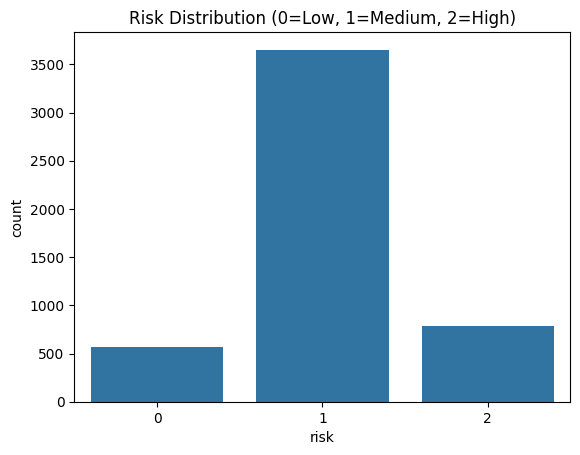

risk
1    3652
2     784
0     564
Name: count, dtype: int64


In [3]:
sns.countplot(x='risk', data=df)
plt.title('Risk Distribution (0=Low, 1=Medium, 2=High)')
plt.show()
print(df['risk'].value_counts())

## Feature Engineering

In [4]:
df['temp_pressure'] = df['temperature'] * df['pressure']
df['pressure_ratio'] = df['pressure'] / df['flow_rate']
df['level_deviation'] = np.abs(df['level'] - 50)

df.head()

,temperature,pressure,flow_rate,level,vibration,risk,temp_pressure,pressure_ratio,level_deviation
0,87.454012,10.904533,249.456327,49.967024,7.299983,1,953.645141,0.043713,0.032976
1,145.071431,12.101535,233.164838,74.674677,1.845120,1,1755.586980,0.051901,24.674677
2,123.199394,17.818211,170.461565,56.266678,3.466397,2,2195.192788,0.104529,6.266678
3,109.865848,10.100066,342.906668,8.330258,6.632806,1,1109.652297,0.029454,41.669742
4,65.601864,18.044745,290.649664,18.558024,4.820893,1,1183.768926,0.062084,31.441976


## Prepare Data For Training

In [5]:
FeatureCols = ['temperature', 'pressure', 'flow_rate', 'level', 'vibration']

X = df[FeatureCols]
y = df['risk']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Training size: 4000
Test size: 1000


## Train XGBoost Model

In [6]:
model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Evaluation

Classification Report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       122
           1       1.00      1.00      1.00       733
           2       0.99      0.99      0.99       145

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000



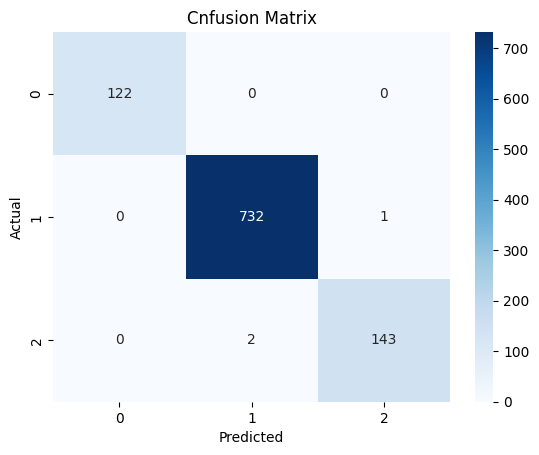

In [7]:
print("Classification Report: ")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Cnfusion Matrix')
plt.show()

## Save Model & Scaler

In [8]:
with open('risk_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved")

Model and scaler saved


## Root Cause Analysis

In [9]:
def ExplainRisk(temperature, pressure, vibration):
    reasons = []
    if temperature > 100:
        reasons.append("High temperature")
    if pressure > 15: 
        reasons.append("High pressure")
    if vibration > 8:
        reasons.append("High vibration")
    
    if len(reasons) == 0:
        return "Normal"
    return " - ".join(reasons)

## Test Prediction With Reasons

In [11]:
sample_temp, sample_press, sample_vib = 110, 16, 6

sample = np.array([[sample_temp, sample_press, 300, 50, sample_vib]])
sample_scaled = scaler.transform(sample)
pred = model.predict(sample_scaled)[0]

risk_map = {0: "Low", 1: "Medium", 2: "High"}
print(f"Temperature: {sample_temp}, Pressure: {sample_press}, Vibration: {sample_vib}")
print(f"Predicted Risk: {risk_map[pred]}")
print(f"Reason: {ExplainRisk(sample_temp, sample_press, sample_vib)}")

Temperature: 110, Pressure: 16, Vibration: 6
Predicted Risk: High
Reason: High temperature - High pressure


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
